In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive
from torch.utils.data import TensorDataset, DataLoader

# Keeping the seed fixed so the results stay reproducible
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cpu


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Loading the tabular dataset from the student wellness dataset
tabular_base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/tabular"

train_tabular_path = os.path.join(tabular_base_path, "train.csv")
test_tabular_path = os.path.join(tabular_base_path, "test.csv")

train_tabular_df = pd.read_csv(train_tabular_path)
test_tabular_df = pd.read_csv(test_tabular_path)

print("Train shape:", train_tabular_df.shape)
print("Test shape:", test_tabular_df.shape)
train_tabular_df.head()

Train shape: (240, 13)
Test shape: (80, 13)


,sample_id,sleep_hours,study_hours,attendance_pct,stress_score,caffeine_cups,exercise_minutes,screen_time_hours,assignment_delay_days,social_minutes,mood_score,label,label_id
0,train_0000,8.18,1.46,96.50,29.41,0.00,31.98,4.65,0.18,59.80,7.15,low_risk,0
1,train_0001,7.33,4.78,85.40,56.27,2.13,21.41,6.44,0.54,55.54,6.25,moderate_risk,1
2,train_0002,5.49,4.82,84.34,68.45,2.50,14.48,8.14,3.57,34.95,4.93,high_risk,2
3,train_0003,5.88,6.09,64.93,79.86,4.23,19.29,8.86,4.16,5.11,3.65,critical_risk,3
4,train_0004,8.45,3.04,88.01,22.32,1.08,47.19,5.55,0.72,68.15,8.07,low_risk,0


In [4]:
# Turning the text labels into numeric classes
label_to_index = {
    label: idx for idx, label in enumerate(sorted(train_tabular_df["label"].unique()))
}

index_to_label = {idx: label for label, idx in label_to_index.items()}

train_tabular_df["label_id"] = train_tabular_df["label"].map(label_to_index)
test_tabular_df["label_id"] = test_tabular_df["label"].map(label_to_index)

print(label_to_index)

{'critical_risk': 0, 'high_risk': 1, 'low_risk': 2, 'moderate_risk': 3}


In [5]:
# Keeping only numeric feature columns
excluded_columns = ["label", "label_id"]

numeric_feature_columns = [
    col for col in train_tabular_df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(train_tabular_df[col])
]

X_train_full = train_tabular_df[numeric_feature_columns].values
y_train_full = train_tabular_df["label_id"].values

X_test = test_tabular_df[numeric_feature_columns].values
y_test = test_tabular_df["label_id"].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (192, 10)
Validation shape: (48, 10)
Test shape: (80, 10)


In [6]:
# Preparing TensorFlow datasets
batch_size = 16

tf_train_ds = tf.data.Dataset.from_tensor_slices((X_train.astype(np.float32), y_train.astype(np.int32)))
tf_val_ds = tf.data.Dataset.from_tensor_slices((X_val.astype(np.float32), y_val.astype(np.int32)))
tf_test_ds = tf.data.Dataset.from_tensor_slices((X_test.astype(np.float32), y_test.astype(np.int32)))

tf_train_ds = tf_train_ds.shuffle(len(X_train), seed=SEED).batch(batch_size)
tf_val_ds = tf_val_ds.batch(batch_size)
tf_test_ds = tf_test_ds.batch(batch_size)

In [7]:
# Preparing PyTorch datasets and dataloaders
X_train_torch = torch.tensor(X_train, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.long)

X_val_torch = torch.tensor(X_val, dtype=torch.float32)
y_val_torch = torch.tensor(y_val, dtype=torch.long)

X_test_torch = torch.tensor(X_test, dtype=torch.float32)
y_test_torch = torch.tensor(y_test, dtype=torch.long)

torch_train_loader = DataLoader(TensorDataset(X_train_torch, y_train_torch), batch_size=batch_size, shuffle=True)
torch_val_loader = DataLoader(TensorDataset(X_val_torch, y_val_torch), batch_size=batch_size, shuffle=False)
torch_test_loader = DataLoader(TensorDataset(X_test_torch, y_test_torch), batch_size=batch_size, shuffle=False)

In [8]:
# This is a simple TensorFlow model that I will train with a custom loop
tf_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(label_to_index), activation="softmax")
])

tf_loss_fn = keras.losses.SparseCategoricalCrossentropy()
tf_optimizer = keras.optimizers.Adam(learning_rate=1e-3)

In [9]:
# Custom train and validation steps for TensorFlow
@tf.function
def tf_train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        predictions = tf_model(x_batch, training=True)
        loss = tf_loss_fn(y_batch, predictions)

    gradients = tape.gradient(loss, tf_model.trainable_variables)
    tf_optimizer.apply_gradients(zip(gradients, tf_model.trainable_variables))

    predicted_classes = tf.argmax(predictions, axis=1, output_type=tf.int32)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(y_batch, predicted_classes), tf.float32))
    return loss, accuracy

@tf.function
def tf_val_step(x_batch, y_batch):
    predictions = tf_model(x_batch, training=False)
    loss = tf_loss_fn(y_batch, predictions)

    predicted_classes = tf.argmax(predictions, axis=1, output_type=tf.int32)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(y_batch, predicted_classes), tf.float32))
    return loss, accuracy

In [10]:
# Running the TensorFlow custom training loop
tf_epochs = 20
tf_train_acc_history = []
tf_val_acc_history = []

for epoch in range(tf_epochs):
    train_losses = []
    train_accuracies = []

    for x_batch, y_batch in tf_train_ds:
        loss, acc = tf_train_step(x_batch, y_batch)
        train_losses.append(loss.numpy())
        train_accuracies.append(acc.numpy())

    val_losses = []
    val_accuracies = []

    for x_batch, y_batch in tf_val_ds:
        loss, acc = tf_val_step(x_batch, y_batch)
        val_losses.append(loss.numpy())
        val_accuracies.append(acc.numpy())

    mean_train_acc = np.mean(train_accuracies)
    mean_val_acc = np.mean(val_accuracies)

    tf_train_acc_history.append(mean_train_acc)
    tf_val_acc_history.append(mean_val_acc)

    print(
        f"TF Epoch {epoch+1:02d} | "
        f"Train Acc: {mean_train_acc:.4f} | "
        f"Val Acc: {mean_val_acc:.4f}"
    )

TF Epoch 01 | Train Acc: 0.3802 | Val Acc: 0.3750
TF Epoch 02 | Train Acc: 0.4948 | Val Acc: 0.6458
TF Epoch 03 | Train Acc: 0.6406 | Val Acc: 0.6250
TF Epoch 04 | Train Acc: 0.5990 | Val Acc: 0.6042
TF Epoch 05 | Train Acc: 0.6458 | Val Acc: 0.6042
TF Epoch 06 | Train Acc: 0.6198 | Val Acc: 0.7083
TF Epoch 07 | Train Acc: 0.7031 | Val Acc: 0.7917
TF Epoch 08 | Train Acc: 0.7396 | Val Acc: 0.8542
TF Epoch 09 | Train Acc: 0.8073 | Val Acc: 0.8750
TF Epoch 10 | Train Acc: 0.8021 | Val Acc: 0.8958
TF Epoch 11 | Train Acc: 0.8542 | Val Acc: 0.9167
TF Epoch 12 | Train Acc: 0.9323 | Val Acc: 0.9375
TF Epoch 13 | Train Acc: 0.9115 | Val Acc: 0.9375
TF Epoch 14 | Train Acc: 0.9010 | Val Acc: 0.9375
TF Epoch 15 | Train Acc: 0.9479 | Val Acc: 0.9375
TF Epoch 16 | Train Acc: 0.9792 | Val Acc: 0.9375
TF Epoch 17 | Train Acc: 0.9479 | Val Acc: 0.9375
TF Epoch 18 | Train Acc: 0.9688 | Val Acc: 0.9375
TF Epoch 19 | Train Acc: 0.9271 | Val Acc: 0.9583
TF Epoch 20 | Train Acc: 0.9479 | Val Acc: 0.9375


In [11]:
# Evaluating the TensorFlow custom-loop model on the test set
tf_test_accuracies = []

for x_batch, y_batch in tf_test_ds:
    _, acc = tf_val_step(x_batch, y_batch)
    tf_test_accuracies.append(acc.numpy())

tf_test_acc = np.mean(tf_test_accuracies)
print("TensorFlow Custom Loop Test Accuracy:", round(tf_test_acc, 4))

TensorFlow Custom Loop Test Accuracy: 0.95


In [12]:
# This is a simple PyTorch model that I will also train with a custom loop
class TorchTabularNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_model = TorchTabularNet(X_train.shape[1], len(label_to_index)).to(device)

torch_loss_fn = nn.CrossEntropyLoss()
torch_optimizer = optim.Adam(torch_model.parameters(), lr=1e-3)

print("Using device:", device)

Using device: cpu


In [13]:
# Running the PyTorch custom training loop
torch_epochs = 20
torch_train_acc_history = []
torch_val_acc_history = []

for epoch in range(torch_epochs):
    torch_model.train()

    correct_train = 0
    total_train = 0

    for xb, yb in torch_train_loader:
        xb, yb = xb.to(device), yb.to(device)

        torch_optimizer.zero_grad()
        logits = torch_model(xb)
        loss = torch_loss_fn(logits, yb)
        loss.backward()
        torch_optimizer.step()

        preds = logits.argmax(dim=1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)

    train_acc = correct_train / total_train
    torch_train_acc_history.append(train_acc)

    torch_model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for xb, yb in torch_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = torch_model(xb)
            preds = logits.argmax(dim=1)

            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)

    val_acc = correct_val / total_val
    torch_val_acc_history.append(val_acc)

    print(
        f"Torch Epoch {epoch+1:02d} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Torch Epoch 01 | Train Acc: 0.2656 | Val Acc: 0.2917
Torch Epoch 02 | Train Acc: 0.4427 | Val Acc: 0.5208
Torch Epoch 03 | Train Acc: 0.5052 | Val Acc: 0.5625
Torch Epoch 04 | Train Acc: 0.5260 | Val Acc: 0.5417
Torch Epoch 05 | Train Acc: 0.5365 | Val Acc: 0.6042
Torch Epoch 06 | Train Acc: 0.6042 | Val Acc: 0.6875
Torch Epoch 07 | Train Acc: 0.6719 | Val Acc: 0.7708
Torch Epoch 08 | Train Acc: 0.7240 | Val Acc: 0.8750
Torch Epoch 09 | Train Acc: 0.8229 | Val Acc: 0.9167
Torch Epoch 10 | Train Acc: 0.8802 | Val Acc: 0.9167
Torch Epoch 11 | Train Acc: 0.9010 | Val Acc: 0.9375
Torch Epoch 12 | Train Acc: 0.9115 | Val Acc: 0.9583
Torch Epoch 13 | Train Acc: 0.9375 | Val Acc: 0.9583
Torch Epoch 14 | Train Acc: 0.9479 | Val Acc: 0.9375
Torch Epoch 15 | Train Acc: 0.9531 | Val Acc: 0.9375
Torch Epoch 16 | Train Acc: 0.9740 | Val Acc: 0.9792
Torch Epoch 17 | Train Acc: 0.9635 | Val Acc: 0.9583
Torch Epoch 18 | Train Acc: 0.9688 | Val Acc: 0.9375
Torch Epoch 19 | Train Acc: 0.9740 | Val Acc: 

In [14]:
# Evaluating the PyTorch custom-loop model on the test set
torch_model.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for xb, yb in torch_test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = torch_model(xb)
        preds = logits.argmax(dim=1)

        correct_test += (preds == yb).sum().item()
        total_test += yb.size(0)

torch_test_acc = correct_test / total_test
print("PyTorch Custom Loop Test Accuracy:", round(torch_test_acc, 4))

PyTorch Custom Loop Test Accuracy: 1.0


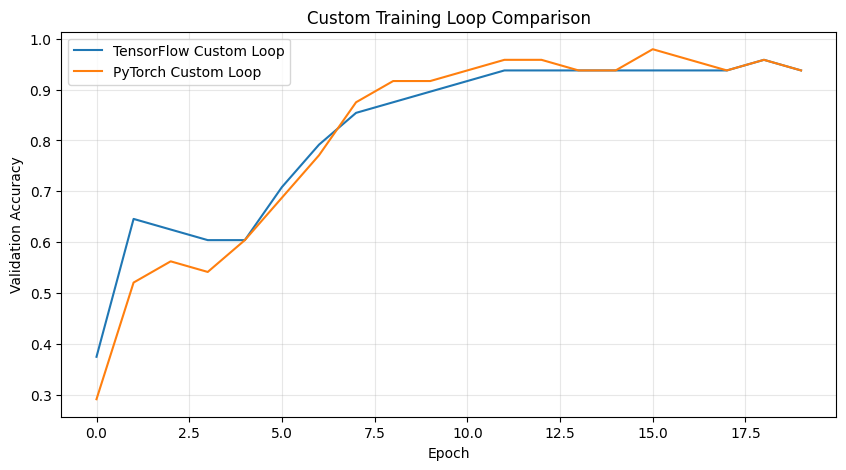

In [15]:
# Comparing the validation accuracy curves from the TensorFlow and PyTorch custom loops
plt.figure(figsize=(10, 5))
plt.plot(tf_val_acc_history, label="TensorFlow Custom Loop")
plt.plot(torch_val_acc_history, label="PyTorch Custom Loop")
plt.title("Custom Training Loop Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Looking at a few predictions from both models
tf_sample_predictions = tf_model.predict(X_test[:8], verbose=0)
tf_pred_classes = np.argmax(tf_sample_predictions, axis=1)

print("TensorFlow sample predictions")
for i in range(4):
    print("True Label     :", index_to_label[y_test[i]])
    print("Predicted Label:", index_to_label[tf_pred_classes[i]])
    print("-" * 45)

torch_model.eval()
with torch.no_grad():
    torch_sample_predictions = torch_model(torch.tensor(X_test[:8], dtype=torch.float32).to(device))
    torch_pred_classes = torch.argmax(torch_sample_predictions, dim=1).cpu().numpy()

print("\nPyTorch sample predictions")
for i in range(4):
    print("True Label     :", index_to_label[y_test[i]])
    print("Predicted Label:", index_to_label[torch_pred_classes[i]])
    print("-" * 45)

TensorFlow sample predictions
True Label     : low_risk
Predicted Label: low_risk
---------------------------------------------
True Label     : critical_risk
Predicted Label: critical_risk
---------------------------------------------
True Label     : high_risk
Predicted Label: high_risk
---------------------------------------------
True Label     : moderate_risk
Predicted Label: moderate_risk
---------------------------------------------

PyTorch sample predictions
True Label     : low_risk
Predicted Label: low_risk
---------------------------------------------
True Label     : critical_risk
Predicted Label: critical_risk
---------------------------------------------
True Label     : high_risk
Predicted Label: high_risk
---------------------------------------------
True Label     : moderate_risk
Predicted Label: moderate_risk
---------------------------------------------


In [17]:
# Final summary so the main result is easy to explain in the video
print("Colab 9 Results Summary")
print("-" * 45)
print(f"TensorFlow Custom Loop Accuracy : {tf_test_acc:.4f}")
print(f"PyTorch Custom Loop Accuracy    : {torch_test_acc:.4f}")

Colab 9 Results Summary
---------------------------------------------
TensorFlow Custom Loop Accuracy : 0.9500
PyTorch Custom Loop Accuracy    : 1.0000


### Final Observation

In this notebook, I implemented custom training loops in both TensorFlow and PyTorch on the same tabular classification task. Instead of using high-level training APIs like `model.fit()`, I manually handled the forward pass, loss calculation, gradient updates, and validation tracking. This notebook helped me understand the training process much more clearly by showing the steps that deep learning frameworks usually automate for us.